## 1. Import Libraries

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math 
sns.set_theme(style='whitegrid')

## 2. Load the Dataset

In [28]:
df= pd.read_csv('dataset/heart_failure_clinical_records_dataset.csv')
y_target = 'DEATH_EVENT'
df.head(3)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1


## 3. Dataset Overview

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [30]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


## 4. Missing Valus & Duplicated Analysis

In [31]:
missing = pd.DataFrame({
    'Missing Count':df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum()/len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values(by='Missing Percentage',ascending=True)
print('Colmuns with Missing values')
missing

Colmuns with Missing values


,Missing Count,Missing Percentage


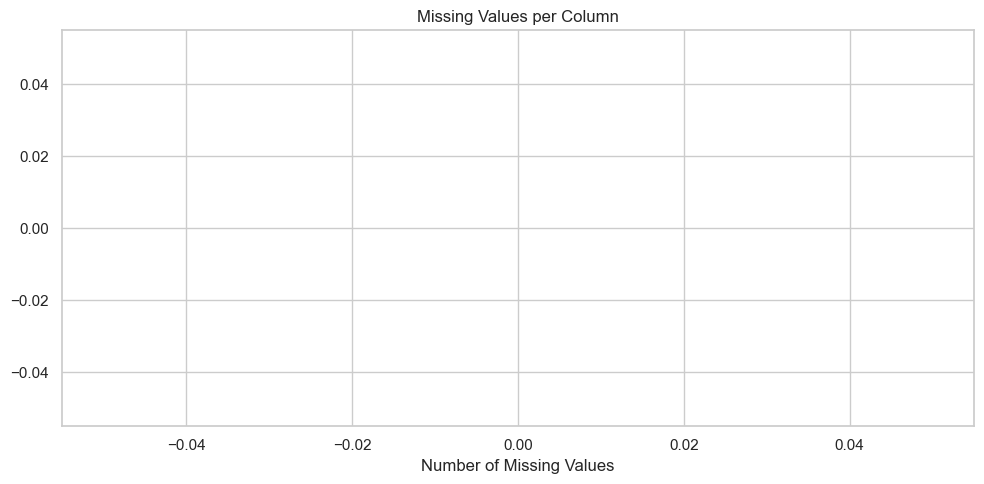

In [32]:
fig,ax = plt.subplots(figsize=(10,5))
ax.barh(missing.index,missing['Missing Count'].values,color='#e74c3c')
ax.set_xlabel("Number of Missing Values")
ax.set_title("Missing Values per Column")
for i,v in enumerate(missing['Missing Count'].values):
    if v > 0:
        ax.text(v+5,i,str(v),va='center',fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
duplicate = pd.DataFrame({
    'Duplicate Count':df.duplicated().sum(),
    'Duplicate Percentage': (df.duplicated().sum()/len(df) * 100).round(2)
},index=['Total Dataset'])
duplicate = duplicate[duplicate['Duplicate Count'] > 0].sort_values(by='Duplicate Percentage',ascending=True)
print('Colmuns with Duplicate values')
duplicate

Colmuns with Duplicate values


,Duplicate Count,Duplicate Percentage


## 5. Target Variable Analysis

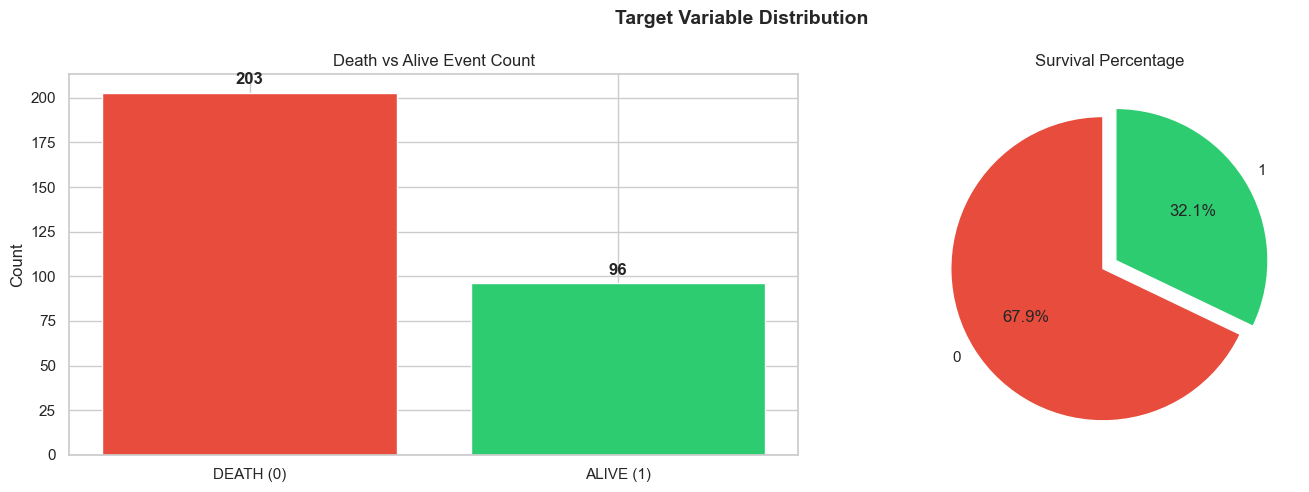

rate_0: 67.89%
rate_1: 32.11%


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
eventDead_count = df[y_target].value_counts()
labels_x = eventDead_count.index
# Count plot
axes[0].bar(["DEATH (0)", "ALIVE (1)"], eventDead_count.values,color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Death vs Alive Event Count")
axes[0].set_ylabel("Count")
for i, v in enumerate(eventDead_count.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")


axes[1].pie(eventDead_count.values, labels=labels_x,
            autopct="%1.1f%%", colors=["#e74c3c", "#2ecc71"],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title("Survival Percentage")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

for i,_ in enumerate(labels_x):
    label = (len(df[df[y_target] == labels_x[i]] )/ len(df))
    print(f'rate_{labels_x[i]}: {label:.2%}')

In [35]:
df['DEATH_EVENT'].describe()

count    299.00000
mean       0.32107
std        0.46767
min        0.00000
25%        0.00000
50%        0.00000
75%        1.00000
max        1.00000
Name: DEATH_EVENT, dtype: float64

## 6. Univariate Analysis — Numerical Features

In [36]:
feature_numerik = df.select_dtypes(include=[np.number]).columns.to_list()
ignored_features = [y_target]
feature_numerik = [col for col in feature_numerik if col not in ignored_features]

print(f'Numeric features ({len(feature_numerik)}):')
print(feature_numerik[:30])

Numeric features (12):
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']


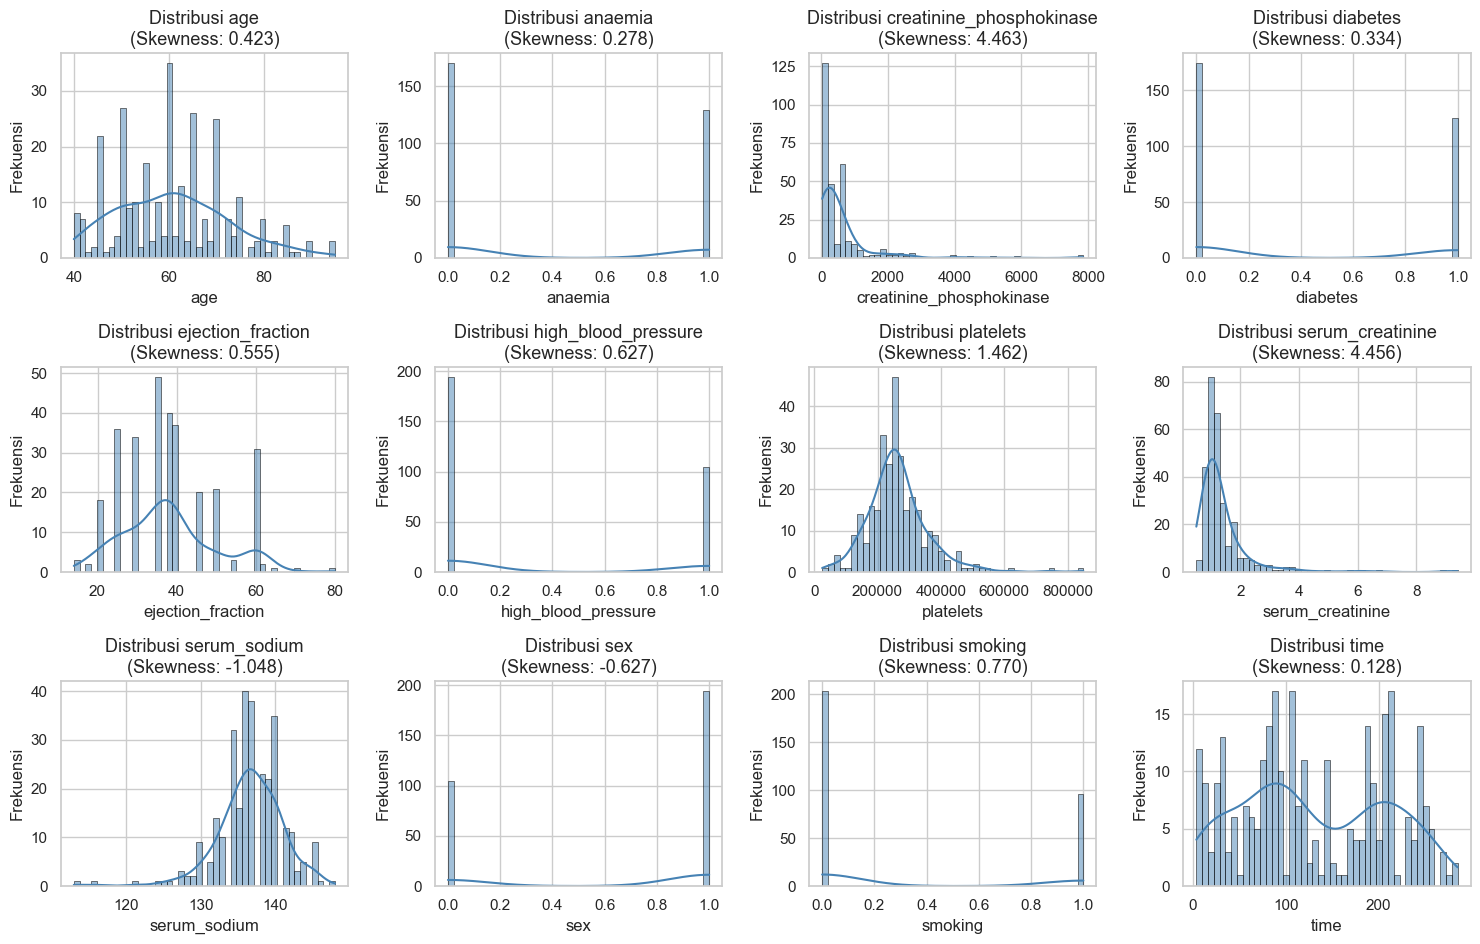

In [37]:
n_show = len(feature_numerik)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i,feature in enumerate(feature_numerik):
    feat_skew = df[feature].skew()
    sns.histplot(df[feature],ax=axes[i],kde=True,color='steelblue',edgecolor='black',bins=45)
    axes[i].set_title( f"Distribusi {feature}\n(Skewness: {feat_skew:.3f})",fontsize=13)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel("Frekuensi", fontsize=12)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

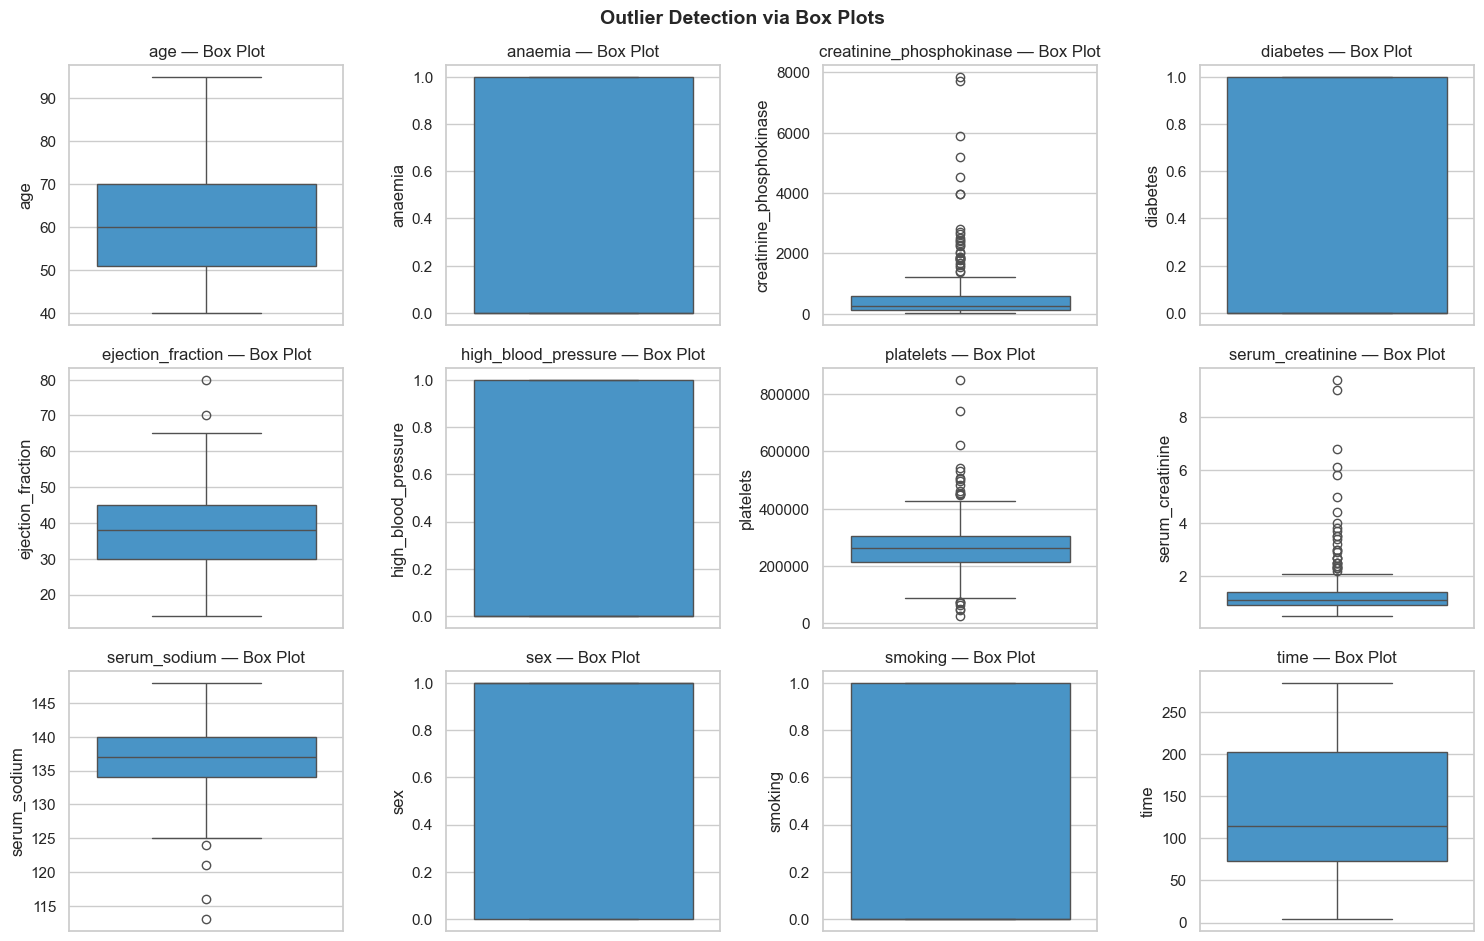

In [38]:
n_show = len(feature_numerik)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i, col in enumerate(feature_numerik):
    sns.boxplot(y=df[col], ax=axes[i], color="#3498db")
    axes[i].set_title(f"{col} — Box Plot")

plt.suptitle("Outlier Detection via Box Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Bivariate Analysis — Features Numerik VS Target

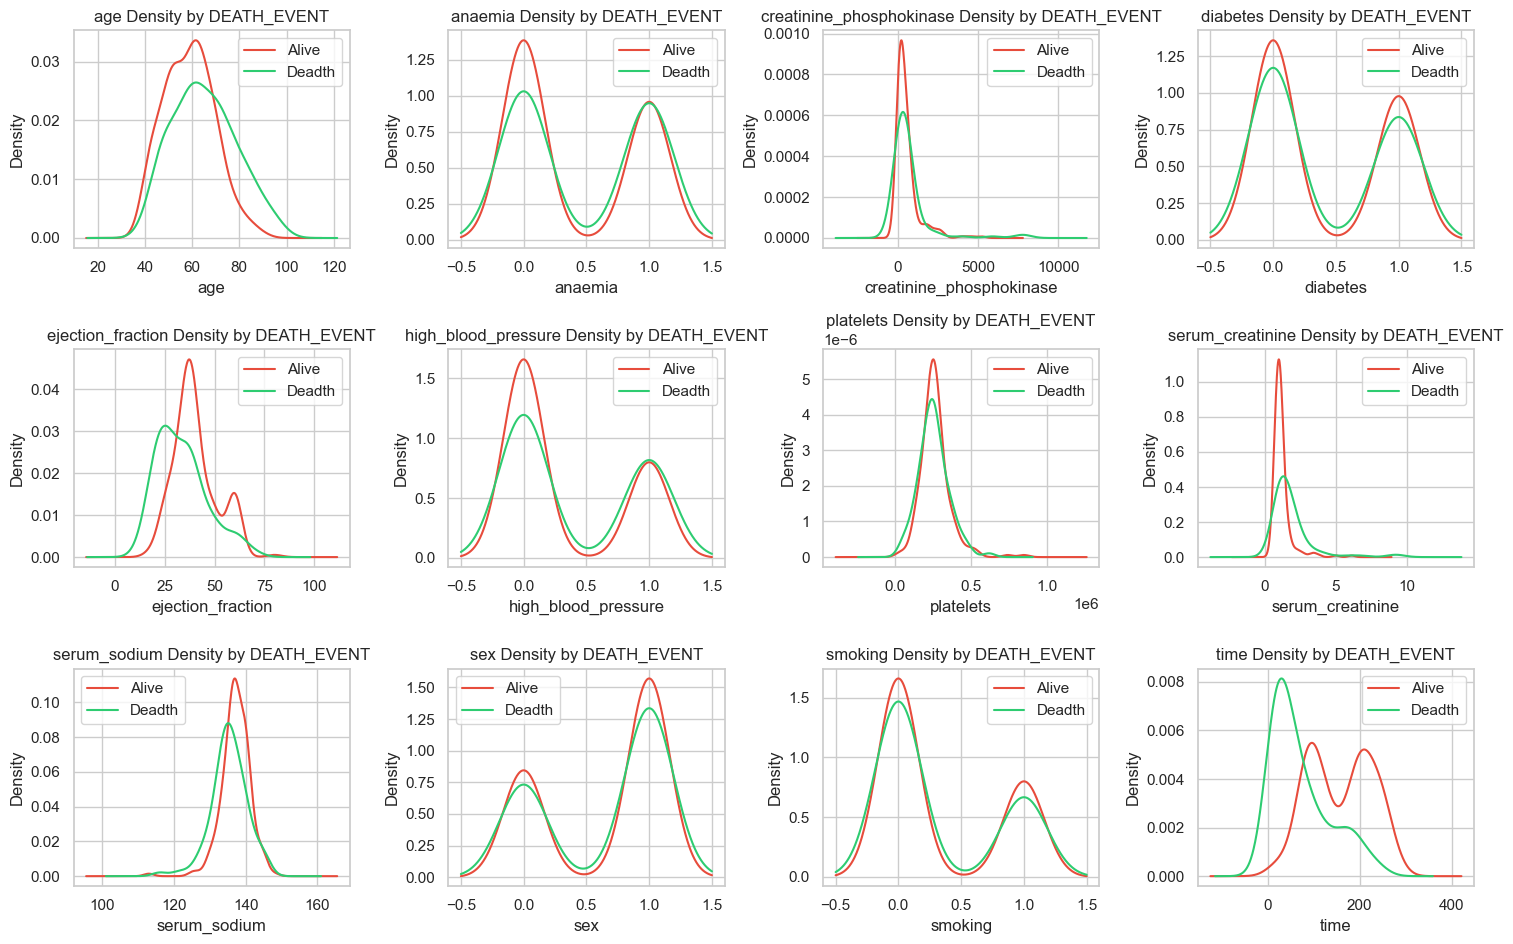

In [39]:
n_show = len(feature_numerik)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i,col in enumerate(feature_numerik):
    df[df[y_target] == 0][col].dropna().plot.kde(ax=axes[i],color="#e74c3c",label='Alive')
    df[df[y_target] == 1][col].dropna().plot.kde(ax=axes[i],color="#2ecc71",label='Deadth')
    axes[i].set_title(f'{col} Density by {y_target}')
    axes[i].set_xlabel(f'{col}')
    axes[i].legend()
plt.tight_layout()
plt.show()

## 8. Multivariat Analysis

In [40]:
feature_numerik = df.select_dtypes(include=[np.number]).columns.to_list()
corrs_all = df[feature_numerik].corr()[y_target].abs().sort_values(ascending=False)
top_features = [x for x in corrs_all.index if x != y_target][:20]
print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
time                        0.527
serum_creatinine            0.294
ejection_fraction           0.269
age                         0.254
serum_sodium                0.195
high_blood_pressure         0.079
anaemia                     0.066
creatinine_phosphokinase    0.063
platelets                   0.049
smoking                     0.013
sex                         0.004
diabetes                    0.002
Name: DEATH_EVENT, dtype: float64


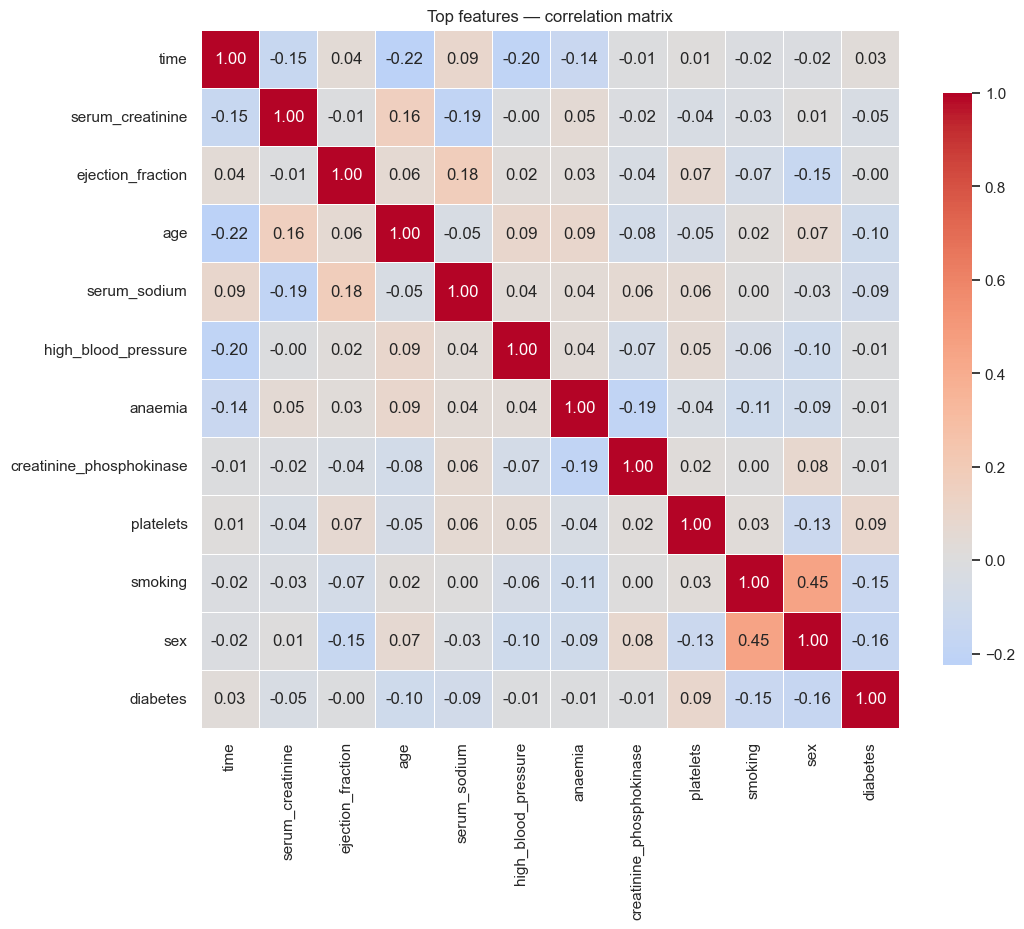

In [41]:
corr_matrix = df[top_features].corr()
plt.figure(figsize=(11,10))
sns.heatmap(corr_matrix,annot=True,fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix')
plt.tight_layout()
plt.show()

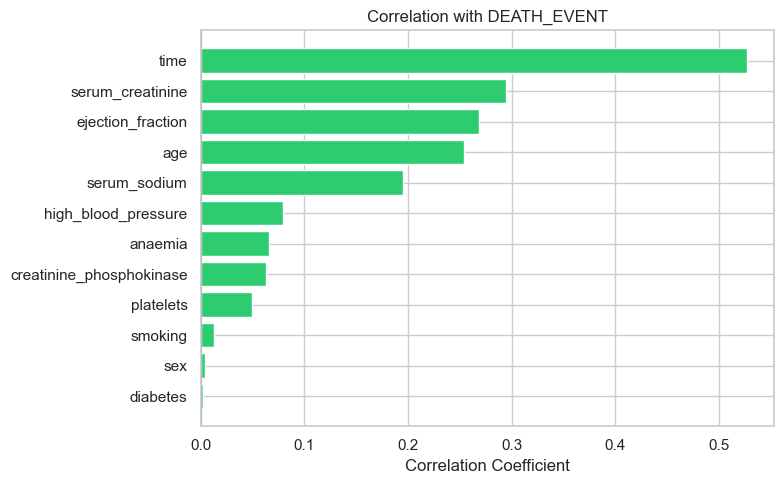

In [42]:
# Correlation with target
target_corr = df[feature_numerik].corr()[y_target].abs().drop(y_target).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_title(f"Correlation with {y_target}")
ax.set_xlabel("Correlation Coefficient")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## 9.Summary of EDA Findings

In [43]:
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Target mean', 'Target median',
               'Target stddev', 'Target min', 'Target max', 'Target skewness',
               'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df), df.shape[1] - 1,
        round(df[y_target].mean(), 2),
        round(df[y_target].median(), 2),
        round(df[y_target].std(), 2),
        round(df[y_target].min(), 2),
        round(df[y_target].max(), 2),
        round(df[y_target].skew(), 3),
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,299
1,Total features,12
2,Target mean,0.32
3,Target median,0.0
4,Target stddev,0.47
5,Target min,0
6,Target max,1
7,Target skewness,0.77
8,Top correlated feature,time
9,Top correlation value,0.527
